In [1]:
# Install required packages
install.packages("dplyr", repos = "https://cloud.r-project.org")

# Load package
library(dplyr)

cat("Packages loaded successfully.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Packages loaded successfully.


In [2]:
# ============================================
# LOAD UCI HEART DISEASE DATASET
# ============================================

heart_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

heart_data <- read.csv(
  heart_url,
  header = FALSE,
  na.strings = "?"
)

# Assign column names
colnames(heart_data) <- c(
  "age",
  "sex",
  "cp",
  "trestbps",
  "chol",
  "fbs",
  "restecg",
  "thalach",
  "exang",
  "oldpeak",
  "slope",
  "ca",
  "thal",
  "target"
)

# Display first few rows
head(heart_data)

# Dataset dimensions
cat("Rows:", nrow(heart_data), "\n")
cat("Columns:", ncol(heart_data), "\n")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


Rows: 303 
Columns: 14 


In [3]:
# ============================================
# INTRODUCE ARTIFICIAL DATA-ENTRY PROBLEMS
# ============================================

set.seed(123)

# Create a copy
heart_data_dirty <- heart_data

# Introduce negative BP values
heart_data_dirty$trestbps[c(10, 50, 100)] <- c(-120, -80, -150)

# Introduce missing BP values
heart_data_dirty$trestbps[c(20, 60, 120)] <- NA

# Introduce extreme BP values greater than 300
heart_data_dirty$trestbps[c(30, 70, 150)] <- c(310, 350, 400)

# Display affected rows
heart_data_dirty[c(10,20,30,50,60,70,100,120,150),
                 c("age", "trestbps", "chol")]

,age,trestbps,chol
,<dbl>,<dbl>,<dbl>
10,53,-120,203
20,49,NA,266
30,40,310,167
50,53,-80,197
60,51,NA,213
70,46,350,231
100,48,-150,222
120,65,NA,254
150,60,400,318


## Custom BP cleaning function

In [4]:
# ============================================
# CUSTOM BP CLEANING FUNCTION
# ============================================

clean_bp <- function(bp) {

  if (is.na(bp)) {
    return(NA)

  } else if (bp < 0) {
    return(NA)

  } else if (bp > 250) {
    return(250)

  } else {
    return(bp)
  }
}

# Test the function
test_values <- c(-100, NA, 120, 180, 300, 400)

cleaned_test_values <- sapply(test_values, clean_bp)

cat("Original values:\n")
print(test_values)

cat("\nCleaned values:\n")
print(cleaned_test_values)

Original values:
[1] -100   NA  120  180  300  400

Cleaned values:
[1]  NA  NA 120 180 250 250


## Apply cleaning function

In [5]:
# ============================================
# APPLY CUSTOM FUNCTION
# ============================================

heart_data_cleaned <- heart_data_dirty

heart_data_cleaned$trestbps <- sapply(
  heart_data_cleaned$trestbps,
  clean_bp
)

# Display BP before and after cleaning
comparison <- data.frame(
  Before = heart_data_dirty$trestbps,
  After = heart_data_cleaned$trestbps
)

head(comparison, 20)

,Before,After
,<dbl>,<dbl>
1,145,145
2,160,160
3,120,120
4,130,130
5,130,130
6,120,120
7,140,140
8,120,120
9,130,130


In [6]:
# ============================================
# TRY-CATCH: SAFE MEAN BP
# ============================================

safe_mean_bp <- function(bp) {

  tryCatch({

    if (!is.numeric(bp)) {
      stop("Blood pressure data must be numeric.")
    }

    if (all(is.na(bp))) {
      stop("Cannot calculate mean because all BP values are missing.")
    }

    mean_bp <- mean(bp, na.rm = TRUE)

    return(mean_bp)

  }, warning = function(w) {

    message("Warning while calculating mean BP: ", w$message)
    return(NA)

  }, error = function(e) {

    message("Error while calculating mean BP: ", e$message)
    return(NA)
  })
}

# Calculate mean BP
mean_bp <- safe_mean_bp(heart_data_cleaned$trestbps)

cat("Mean BP:", mean_bp, "\n")

Mean BP: 133.0236 


In [7]:
# ============================================
# TRY-CATCH: CHOLESTEROL / BP RATIO
# ============================================

safe_ratio <- function(chol, bp) {

  tryCatch({

    # Check for missing values
    if (is.na(chol) || is.na(bp)) {
      stop("Cholesterol or BP is missing.")
    }

    # Check numeric values
    if (!is.numeric(chol) || !is.numeric(bp)) {
      stop("Cholesterol and BP must be numeric.")
    }

    # Check denominator
    if (bp == 0) {
      stop("Cannot divide by zero: BP is 0.")
    }

    # Check invalid values
    if (bp < 0 || chol < 0) {
      stop("Invalid negative value detected.")
    }

    ratio <- chol / bp

    return(ratio)

  }, warning = function(w) {

    message("Warning: ", w$message)
    return(NA)

  }, error = function(e) {

    message("Error calculating ratio: ", e$message)
    return(NA)
  })
}

# Test the function
cat("Valid ratio:\n")
print(safe_ratio(200, 120))

cat("\nMissing BP:\n")
print(safe_ratio(200, NA))

cat("\nZero BP:\n")
print(safe_ratio(200, 0))

cat("\nNegative BP:\n")
print(safe_ratio(200, -50))

Valid ratio:
[1] 1.666667

Missing BP:


Error calculating ratio: Cholesterol or BP is missing.



[1] NA

Zero BP:


Error calculating ratio: Cannot divide by zero: BP is 0.



[1] NA

Negative BP:


Error calculating ratio: Invalid negative value detected.



[1] NA


## Calculate ratio for complete dataset

In [8]:
# ============================================
# CALCULATE CHOL / BP RATIO
# ============================================

heart_data_cleaned$chol_bp_ratio <- mapply(
  safe_ratio,
  heart_data_cleaned$chol,
  heart_data_cleaned$trestbps
)

head(
  heart_data_cleaned[
    c("age", "trestbps", "chol", "chol_bp_ratio")
  ],
  15
)

Error calculating ratio: Cholesterol or BP is missing.

Error calculating ratio: Cholesterol or BP is missing.

Error calculating ratio: Cholesterol or BP is missing.

Error calculating ratio: Cholesterol or BP is missing.

Error calculating ratio: Cholesterol or BP is missing.

Error calculating ratio: Cholesterol or BP is missing.



,age,trestbps,chol,chol_bp_ratio
,<dbl>,<dbl>,<dbl>,<dbl>
1,63,145,233,1.606897
2,67,160,286,1.787500
3,67,120,229,1.908333
4,37,130,250,1.923077
5,41,130,204,1.569231
6,56,120,236,1.966667
7,62,140,268,1.914286
8,57,120,354,2.950000
9,63,130,254,1.953846


## Loop vs Vectorized Cleaning

In [9]:
# ============================================
# LOOP-BASED BP CLEANING
# ============================================

loop_clean_bp <- function(bp_vector) {

  result <- bp_vector

  for (i in seq_along(result)) {

    if (is.na(result[i])) {

      result[i] <- NA

    } else if (result[i] < 0) {

      result[i] <- NA

    } else if (result[i] > 250) {

      result[i] <- 250

    }
  }

  return(result)
}

# Test
loop_result <- loop_clean_bp(heart_data_dirty$trestbps)

head(loop_result, 20)

[1] 145 160 120 130 130 120 140 120 130  NA 140 140 130 120 172 150 110 140 130
[20]  NA

## Vectorized cleaning

In [10]:
# ============================================
# VECTORIZED BP CLEANING
# ============================================

vectorized_clean_bp <- function(bp_vector) {

  result <- bp_vector

  # Negative values become NA
  result[result < 0] <- NA

  # Values above 250 are capped at 250
  result[result > 250] <- 250

  return(result)
}

# Test
vectorized_result <- vectorized_clean_bp(
  heart_data_dirty$trestbps
)

head(vectorized_result, 20)

[1] 145 160 120 130 130 120 140 120 130  NA 140 140 130 120 172 150 110 140 130
[20]  NA

In [11]:
# ============================================
# COMPARE RESULTS
# ============================================

same_result <- identical(
  loop_result,
  vectorized_result
)

cat("Do loop and vectorized methods produce the same result?",
    same_result, "\n")

Do loop and vectorized methods produce the same result? TRUE 


In [12]:
# ============================================
# EXECUTION TIME COMPARISON
# ============================================

loop_time <- system.time({

  for (j in 1:1000) {
    loop_clean_bp(heart_data_dirty$trestbps)
  }
})

vectorized_time <- system.time({

  for (j in 1:1000) {
    vectorized_clean_bp(heart_data_dirty$trestbps)
  }
})

cat("Loop-based execution time:\n")
print(loop_time)

cat("\nVectorized execution time:\n")
print(vectorized_time)

cat("\nComparison:\n")

if (loop_time["elapsed"] > vectorized_time["elapsed"]) {

  cat("Vectorized approach is faster than the loop-based approach.\n")

} else {

  cat("Loop-based approach was faster in this particular run.\n")
}

Loop-based execution time:
   user  system elapsed 
  0.088   0.000   0.088 

Vectorized execution time:
   user  system elapsed 
  0.011   0.000   0.012 

Comparison:
Vectorized approach is faster than the loop-based approach.


In [13]:
# ============================================
# VALIDATE CLEANED DATA
# ============================================

bp <- heart_data_cleaned$trestbps

cat("========== BP VALIDATION ==========\n")

# Missing BP values
missing_bp <- sum(is.na(bp))

cat("Number of missing BP values:", missing_bp, "\n")

# Minimum
cat("Minimum BP:", min(bp, na.rm = TRUE), "\n")

# Maximum
cat("Maximum BP:", max(bp, na.rm = TRUE), "\n")

# Mean
cat("Mean BP:", mean(bp, na.rm = TRUE), "\n")

# Median
cat("Median BP:", median(bp, na.rm = TRUE), "\n")

# Negative values
negative_count <- sum(bp < 0, na.rm = TRUE)

cat("Negative BP values remaining:", negative_count, "\n")

# Values greater than 250
above_250_count <- sum(bp > 250, na.rm = TRUE)

cat("BP values greater than 250 remaining:",
    above_250_count, "\n")

# Final validation
if (negative_count == 0 && above_250_count == 0) {

  cat("\nVALIDATION PASSED: No negative or >250 BP values remain.\n")

} else {

  cat("\nVALIDATION FAILED.\n")
}

========== BP VALIDATION ==========
Number of missing BP values: 6 
Minimum BP: 94 
Maximum BP: 250 
Mean BP: 133.0236 
Median BP: 130 
Negative BP values remaining: 0 
BP values greater than 250 remaining: 0 

VALIDATION PASSED: No negative or >250 BP values remain.


## Save cleaned Heart dataset

In [14]:
write.csv(
  heart_data_cleaned,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

cat("cleaned_heart_data.csv created successfully.\n")

cleaned_heart_data.csv created successfully.


In [15]:
# ============================================
# ADVANCED MISSING DATA HANDLING
# ============================================

install.packages(
  c("dplyr", "naniar", "skimr"),
  repos = "https://cloud.r-project.org"
)

library(dplyr)
library(naniar)
library(skimr)

cat("Lab 4 packages loaded successfully.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




Lab 4 packages loaded successfully.


In [16]:
# ============================================
# LOAD UCI ADULT DATASET
# ============================================

adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult_data <- read.csv(
  adult_url,
  header = FALSE,
  strip.white = TRUE,
  na.strings = "?"
)

# Assign column names
colnames(adult_data) <- c(
  "age",
  "workclass",
  "fnlwgt",
  "education",
  "education_num",
  "marital_status",
  "occupation",
  "relationship",
  "race",
  "sex",
  "capital_gain",
  "capital_loss",
  "hours_per_week",
  "native_country",
  "income"
)

# Display data
head(adult_data)

cat("Rows:", nrow(adult_data), "\n")
cat("Columns:", ncol(adult_data), "\n")

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


Rows: 32561 
Columns: 15 


In [17]:
# ============================================
# INTRODUCE ARTIFICIAL MISSING DATA
# ============================================

set.seed(123)

adult_dirty <- adult_data

# NA
adult_dirty$age[c(10, 20, 30)] <- NA

# NaN
adult_dirty$hours_per_week[c(40, 50)] <- NaN

# Impossible age
adult_dirty$age[c(60, 70)] <- 999

# Blank categorical values
adult_dirty$workclass[c(80, 90)] <- ""
adult_dirty$occupation[c(100, 110)] <- ""

# Display affected records
adult_dirty[c(10,20,30,40,50,60,70,80,90,100,110),
            c("age", "workclass", "occupation", "hours_per_week")]

,age,workclass,occupation,hours_per_week
,<dbl>,<chr>,<chr>,<dbl>
10,NA,Private,Exec-managerial,40
20,NA,Self-emp-not-inc,Exec-managerial,45
30,NA,Private,Craft-repair,40
40,48,Self-emp-not-inc,Prof-specialty,NaN
50,29,Private,Prof-specialty,NaN
60,999,Private,Machine-op-inspct,40
70,999,NA,NA,40
80,31,,Farming-fishing,40
90,43,,Prof-specialty,50


In [18]:
# ============================================
# DETECT NA
# ============================================

cat("Total NA values in dataset:",
    sum(is.na(adult_dirty)), "\n")

# NA values per column
na_summary <- colSums(is.na(adult_dirty))

print(na_summary)

Total NA values in dataset: 4267 
           age      workclass         fnlwgt      education  education_num 
             3           1836              0              0              0 
marital_status     occupation   relationship           race            sex 
             0           1843              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              2            583              0 


In [19]:
# ============================================
# DETECT NaN
# ============================================

# NaN can occur only in numeric columns
nan_summary <- sapply(
  adult_dirty,
  function(x) {

    if (is.numeric(x)) {
      sum(is.nan(x))
    } else {
      0
    }
  }
)

cat("NaN values by variable:\n")

print(nan_summary)

NaN values by variable:
           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              2              0              0 


In [20]:
# ============================================
# DEMONSTRATE NULL
# ============================================

example_object <- NULL

cat("Is example_object NULL?",
    is.null(example_object), "\n")

# Demonstrate NULL behaves differently from NA
example_na <- NA

cat("Is example_na NULL?",
    is.null(example_na), "\n")

cat("Is example_na NA?",
    is.na(example_na), "\n")

# Explanation
cat("\nExplanation:\n")
cat("NULL represents the absence of an R object/value.\n")
cat("NA represents a missing value inside a vector/data frame.\n")
cat("NULL is therefore not normally used as a cell value in a data frame.\n")

Is example_object NULL? TRUE 
Is example_na NULL? FALSE 
Is example_na NA? TRUE 

Explanation:
NULL represents the absence of an R object/value.
NA represents a missing value inside a vector/data frame.
NULL is therefore not normally used as a cell value in a data frame.


In [21]:
# ============================================
# DETECT BLANK STRINGS
# ============================================

blank_workclass <- sum(adult_dirty$workclass == "", na.rm = TRUE)

blank_occupation <- sum(adult_dirty$occupation == "", na.rm = TRUE)

cat("Blank workclass values:", blank_workclass, "\n")
cat("Blank occupation values:", blank_occupation, "\n")

Blank workclass values: 2 
Blank occupation values: 2 


In [22]:
# ============================================
# DETECT IMPOSSIBLE AGE VALUES
# ============================================

invalid_age <- sum(
  adult_dirty$age == 999,
  na.rm = TRUE
)

cat("Number of age = 999 values:",
    invalid_age, "\n")

Number of age = 999 values: 2 


In [23]:
# ============================================
# MISSING VALUE SUMMARY USING NANIAR
# ============================================

missing_summary_before <- naniar::miss_var_summary(
  adult_dirty
)

print(missing_summary_before)

# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation       1843  5.66   
 2 workclass        1836  5.64   
 3 native_country    583  1.79   
 4 age                 3  0.00921
 5 hours_per_week      2  0.00614
 6 fnlwgt              0  0      
 7 education           0  0      
 8 education_num       0  0      
 9 marital_status      0  0      
10 relationship        0  0      
11 race                0  0      
12 sex                 0  0      
13 capital_gain        0  0      
14 capital_loss        0  0      
15 income              0  0      


In [24]:
# ============================================
# CUSTOM MEDIAN IMPUTATION FUNCTION
# ============================================

median_impute <- function(x) {

  # Make sure input is numeric
  if (!is.numeric(x)) {
    stop("Input must be a numeric vector.")
  }

  # Calculate median using valid values
  median_value <- median(
    x,
    na.rm = TRUE
  )

  # Replace NA and NaN with median
  x[is.na(x)] <- median_value

  return(x)
}

# Test function
test_vector <- c(10, 20, NA, 30, NaN, 40)

cat("Original vector:\n")
print(test_vector)

cat("\nAfter median imputation:\n")
print(median_impute(test_vector))

Original vector:
[1]  10  20  NA  30 NaN  40

After median imputation:
[1] 10 20 25 30 25 40


## Cleaning and Treatment

In [25]:
# ============================================
# CLEAN ADULT DATASET
# ============================================

adult_cleaned <- adult_dirty

# --------------------------------------------
# STEP 1: Convert impossible age = 999 to NA
# --------------------------------------------

adult_cleaned$age[
  adult_cleaned$age == 999
] <- NA

# --------------------------------------------
# STEP 2: Replace blank categorical values
# with "Unknown"
# --------------------------------------------

adult_cleaned$workclass[
  adult_cleaned$workclass == ""
] <- "Unknown"

adult_cleaned$occupation[
  adult_cleaned$occupation == ""
] <- "Unknown"

# --------------------------------------------
# STEP 3: Median imputation
# --------------------------------------------

adult_cleaned$age <- median_impute(
  adult_cleaned$age
)

adult_cleaned$fnlwgt <- median_impute(
  adult_cleaned$fnlwgt
)

adult_cleaned$education_num <- median_impute(
  adult_cleaned$education_num
)

adult_cleaned$capital_gain <- median_impute(
  adult_cleaned$capital_gain
)

adult_cleaned$capital_loss <- median_impute(
  adult_cleaned$capital_loss
)

adult_cleaned$hours_per_week <- median_impute(
  adult_cleaned$hours_per_week
)

# --------------------------------------------
# STEP 4: Remove remaining NaN values
# --------------------------------------------

adult_cleaned <- adult_cleaned[
  complete.cases(adult_cleaned),
]

cat("Cleaning completed.\n")
cat("Remaining rows:", nrow(adult_cleaned), "\n")

Cleaning completed.
Remaining rows: 30162 


## Before/After Missing Data

In [26]:
# ============================================
# BEFORE/AFTER MISSING VALUE COMPARISON
# ============================================

before_missing <- sum(is.na(adult_dirty))

after_missing <- sum(is.na(adult_cleaned))

cat("Missing values BEFORE cleaning:",
    before_missing, "\n")

cat("Missing values AFTER cleaning:",
    after_missing, "\n")

# Percentage missing
before_percentage <- (
  before_missing /
  (nrow(adult_dirty) * ncol(adult_dirty))
) * 100

after_percentage <- (
  after_missing /
  (nrow(adult_cleaned) * ncol(adult_cleaned))
) * 100

cat(
  "Percentage missing BEFORE cleaning:",
  round(before_percentage, 2),
  "%\n"
)

cat(
  "Percentage missing AFTER cleaning:",
  round(after_percentage, 2),
  "%\n"
)

Missing values BEFORE cleaning: 4267 
Missing values AFTER cleaning: 0 
Percentage missing BEFORE cleaning: 0.87 %
Percentage missing AFTER cleaning: 0 %


## Complete Cases

In [27]:
# ============================================
# COMPLETE.CASES()
# ============================================

complete_before <- sum(
  complete.cases(adult_dirty)
)

incomplete_before <- sum(
  !complete.cases(adult_dirty)
)

complete_after <- sum(
  complete.cases(adult_cleaned)
)

incomplete_after <- sum(
  !complete.cases(adult_cleaned)
)

cat("Complete rows BEFORE cleaning:",
    complete_before, "\n")

cat("Incomplete rows BEFORE cleaning:",
    incomplete_before, "\n")

cat("Complete rows AFTER cleaning:",
    complete_after, "\n")

cat("Incomplete rows AFTER cleaning:",
    incomplete_after, "\n")

Complete rows BEFORE cleaning: 30157 
Incomplete rows BEFORE cleaning: 2404 
Complete rows AFTER cleaning: 30162 
Incomplete rows AFTER cleaning: 0 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



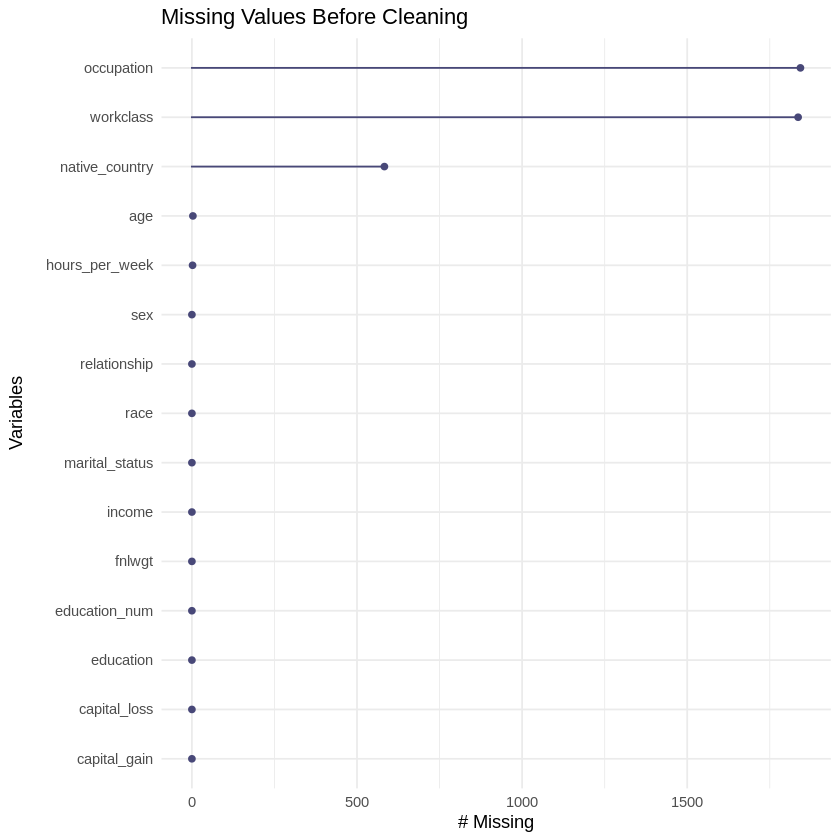

In [29]:
# ============================================
# MISSINGNESS VISUALIZATION
# ============================================

# Install ggplot2 if required
install.packages("ggplot2", repos = "https://cloud.r-project.org")

# Load ggplot2
library(ggplot2)

# Plot missing values
gg_miss_var(adult_dirty) +
  ggtitle("Missing Values Before Cleaning")

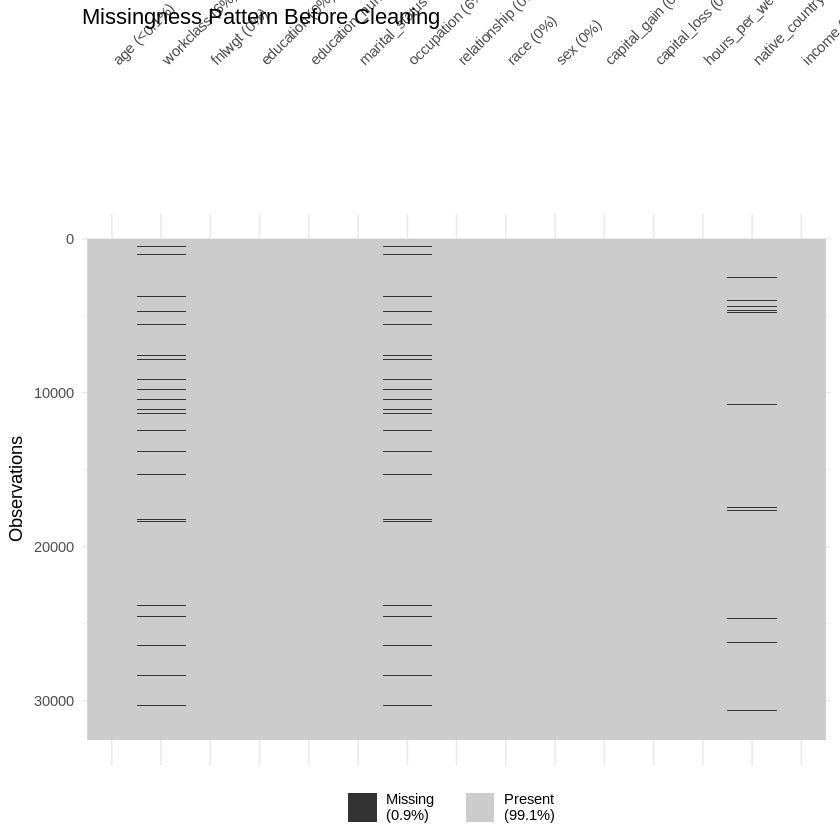

In [30]:
# ============================================
# MISSINGNESS PATTERN
# ============================================

vis_miss(adult_dirty) +
  ggtitle("Missingness Pattern Before Cleaning")

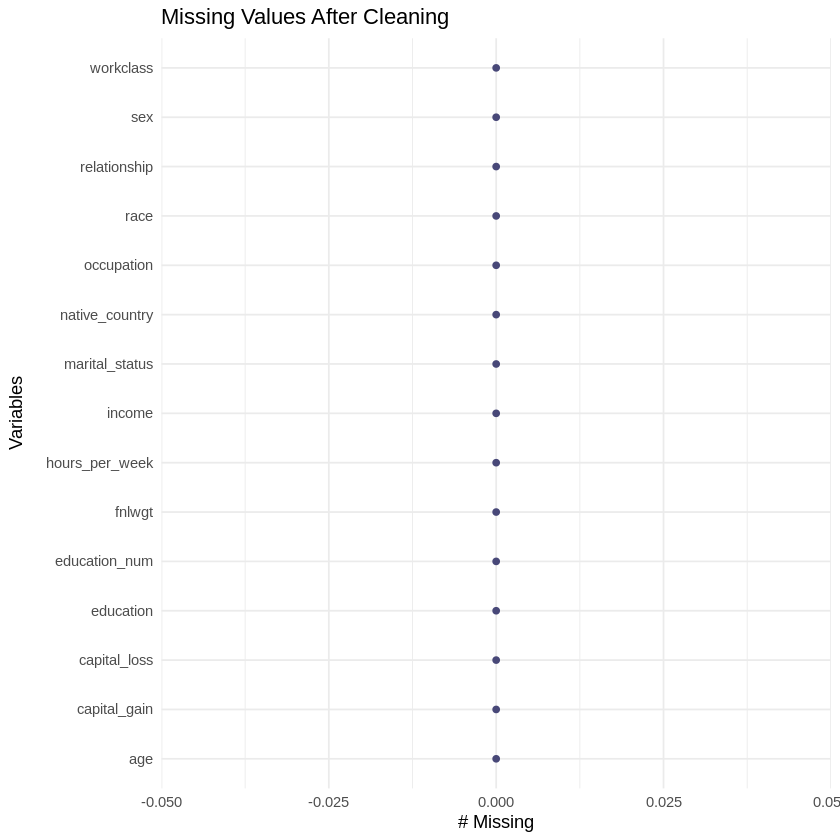

In [31]:
# ============================================
# MISSINGNESS AFTER CLEANING
# ============================================

gg_miss_var(adult_cleaned) +
  ggtitle("Missing Values After Cleaning")

In [32]:
# ============================================
# SKIMR VALIDATION
# ============================================

skim(adult_cleaned)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,7,16,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,5,17,0,15,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,0,1,4,26,0,41,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [33]:
# ============================================
# FINAL VALIDATION
# ============================================

cat("====================================\n")
cat("FINAL DATA VALIDATION\n")
cat("====================================\n")

# Check impossible age
age_999_remaining <- sum(
  adult_cleaned$age == 999,
  na.rm = TRUE
)

cat(
  "Age = 999 remaining:",
  age_999_remaining,
  "\n"
)

# Check blank workclass
blank_workclass_remaining <- sum(
  adult_cleaned$workclass == "",
  na.rm = TRUE
)

cat(
  "Blank workclass values remaining:",
  blank_workclass_remaining,
  "\n"
)

# Check blank occupation
blank_occupation_remaining <- sum(
  adult_cleaned$occupation == "",
  na.rm = TRUE
)

cat(
  "Blank occupation values remaining:",
  blank_occupation_remaining,
  "\n"
)

# Check NA
remaining_na <- sum(
  is.na(adult_cleaned)
)

cat(
  "Remaining NA values:",
  remaining_na,
  "\n"
)

# Check NaN
remaining_nan <- sum(
  sapply(
    adult_cleaned,
    function(x) {

      if (is.numeric(x)) {
        sum(is.nan(x))
      } else {
        0
      }
    }
  )
)

cat(
  "Remaining NaN values:",
  remaining_nan,
  "\n"
)

# Final status
if (
  age_999_remaining == 0 &&
  blank_workclass_remaining == 0 &&
  blank_occupation_remaining == 0 &&
  remaining_na == 0 &&
  remaining_nan == 0
) {

  cat("\nFINAL VALIDATION PASSED.\n")

} else {

  cat("\nSome invalid/missing values remain.\n")
}

FINAL DATA VALIDATION
Age = 999 remaining: 0 
Blank workclass values remaining: 0 
Blank occupation values remaining: 0 
Remaining NA values: 0 
Remaining NaN values: 0 

FINAL VALIDATION PASSED.


In [34]:
# ============================================
# SAVE CLEANED ADULT DATASET
# ============================================

write.csv(
  adult_cleaned,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat("cleaned_adult_data.csv created successfully.\n")

cleaned_adult_data.csv created successfully.


## Download Both CSV Files

In [35]:
# ============================================
# LIST GENERATED FILES
# ============================================

cat("Generated files:\n\n")

print(
  list.files(
    pattern = "cleaned_.*\\.csv$"
  )
)

Generated files:

[1] "cleaned_adult_data.csv" "cleaned_heart_data.csv"


In [38]:
# ============================================
# DOWNLOAD FILES IN GOOGLE COLAB
# ============================================

# Run these if using R Colab

system("ls -lh cleaned_*.csv")